In [ ]:
import os, glob

print('Features files:', len(glob.glob('data/ExtraSensory.per_uuid_features_labels/*.csv.gz')))
print('data/cv_5_folds files:', len(glob.glob('data/cv_5_folds/*')))
print(sorted([os.path.basename(p) for p in glob.glob('data/cv_5_folds/*')])[:30])

Features files: 60
data/cv5Folds files: 20
['fold_0_test_android_uuids.txt', 'fold_0_test_iphone_uuids.txt', 'fold_0_train_android_uuids.txt', 'fold_0_train_iphone_uuids.txt', 'fold_1_test_android_uuids.txt', 'fold_1_test_iphone_uuids.txt', 'fold_1_train_android_uuids.txt', 'fold_1_train_iphone_uuids.txt', 'fold_2_test_android_uuids.txt', 'fold_2_test_iphone_uuids.txt', 'fold_2_train_android_uuids.txt', 'fold_2_train_iphone_uuids.txt', 'fold_3_test_android_uuids.txt', 'fold_3_test_iphone_uuids.txt', 'fold_3_train_android_uuids.txt', 'fold_3_train_iphone_uuids.txt', 'fold_4_test_android_uuids.txt', 'fold_4_test_iphone_uuids.txt', 'fold_4_train_android_uuids.txt', 'fold_4_train_iphone_uuids.txt']


# 1. Business Understanding

Цель

Разработать proof-of-concept систему «Microbreak Assistant», которая по признакам со смартфонных сенсоров определяет, находится ли пользователь в состоянии LYING_DOWN, SITTING или FIX_walking. Ассистент будет рекомендовать микроперерывы при длительном сидении, избегать уведомлений во время лежания (отдых/сон) и не предпринимать действий, когда пользователь ходит.

Исследовательские вопросы

Обобщаемость на новых пользователей:
Насколько хорошо можно классифицировать состояния LYING_DOWN / SITTING / FIX_walking для ранее не встречавшихся пользователей при user-based cross-validation (5 folds)?

Ошибки и их влияние на продукт:
Какие классы чаще всего путаются между собой (например, walking → sitting или lying ↔ sitting) и как эти ошибки влияют на логику уведомлений о микроперерывах?

Стабильность качества:
Насколько сильно меняются метрики между фолдами (mean ± std), и какие классы наиболее чувствительны к смене группы пользователей?

# 2. Data Understanding

### 2.1 Источник и контекст датасета

Мы используем ExtraSensory Dataset — датасет для распознавания поведенческого контекста “in-the-wild” по сенсорам смартфона и смарт-часов. Он собран с 60 участников и содержит более 300k минут данных; каждая минута имеет сенсорные измерения и размечена контекстными метками, которые пользователи отмечали в приложении (self-report).

### 2.2 Какие сенсоры и что измеряется

Система использует несколько модальностей со смартфона (например, акселерометр, гироскоп, геолокация, аудио, “phone state”) и акселерометр со смарт-часов. Эти разнородные сенсоры важны, потому что в реальных условиях положение телефона и стиль поведения сильно варьируются.

### 2.3 Формат файлов, которые мы используем

Мы работаем не с “сырым” сигналом, а с готовыми признаками (features) и бинарными колонками-метками в файлах ExtraSensory.per_uuid_features_labels (по одному файлу на пользователя/UUID). Такой формат ускоряет работу: можно сразу переходить к подготовке данных и моделированию.

Для честной проверки обобщаемости на новых людей мы используем готовые user-based разбиения из cv_5_folds: в каждом из 5 фолдов перечислены UUID пользователей для train/test (отдельно для Android/iPhone). Мы прогоняем обучение и оценку на всех пяти фолдах и затем усредняем метрики (mean ± std).

### 2.4 Какие метки (labels) мы исследуем

Датасет в целом multi-label: у одной минуты может быть сразу несколько контекстов (например, “sitting + indoors + at home”).
В этом проекте мы фокусируемся на 3 классах, которые напрямую полезны для “Microbreak Assistant”:

LYING_DOWN

SITTING

FIX_walking

Смысл для продукта:

SITTING → потенциально уместно предложить микропаузу,

LYING_DOWN → лучше не мешать (отдых/сон),

FIX_walking → человек уже двигается.

In [2]:
import os, glob
import pandas as pd
import numpy as np

DATA_DIR = "data/ExtraSensory.per_uuid_features_labels"
FOLDS_DIR = "data/cv_5_folds"
TARGET_LABELS = ["LYING_DOWN", "SITTING", "FIX_walking"]

print("User files:", len(glob.glob(f"{DATA_DIR}/*.csv.gz")))
print("Fold files:", len(glob.glob(f"{FOLDS_DIR}/*.txt")))
print("Example fold files:", sorted([os.path.basename(p) for p in glob.glob(f"{FOLDS_DIR}/*.txt")])[:8])

files = sorted(glob.glob(f"{DATA_DIR}/*.csv.gz"))
sample = pd.read_csv(files[0], compression="gzip")

def find_label_col(cols, label):
    cands = [c for c in cols if ("label" in c.lower()) and (label in c)]
    if not cands:
        cands = [c for c in cols if c.endswith(label)]
    return cands[0]

label_cols = [find_label_col(sample.columns, lab) for lab in TARGET_LABELS]

counts = np.zeros(3, dtype=int)
total = 0
for p in files:
    df = pd.read_csv(p, compression="gzip")
    Y = df[label_cols].fillna(0).astype(int).values
    mask = (Y.sum(axis=1) == 1)
    Y = Y[mask]
    if len(Y) == 0:
        continue
    total += len(Y)
    counts += Y.sum(axis=0).astype(int)

print("Total filtered samples:", total)
print("Class counts:", dict(zip(TARGET_LABELS, counts)))

User files: 60
Fold files: 20
Example fold files: ['fold_0_test_android_uuids.txt', 'fold_0_test_iphone_uuids.txt', 'fold_0_train_android_uuids.txt', 'fold_0_train_iphone_uuids.txt', 'fold_1_test_android_uuids.txt', 'fold_1_test_iphone_uuids.txt', 'fold_1_train_android_uuids.txt', 'fold_1_train_iphone_uuids.txt']
Total filtered samples: 262702
Class counts: {'LYING_DOWN': np.int64(104210), 'SITTING': np.int64(136356), 'FIX_walking': np.int64(22136)}


### 2.5 Быстрые описательные статистики по нашей выборке

В локальной копии датасета:

файлов пользователей: 60

после фильтрации под нашу задачу (оставляем минуты, где активен ровно один из трёх лейблов) получаем: 262 702 примера

Распределение классов (после фильтрации):

LYING_DOWN: 104 210

SITTING: 136 356

FIX_walking: 22 136

Эти числа относятся к подвыборке, где активен ровно один из трёх целевых лейблов.

Вывод: классы несбалансированы (walking встречается заметно реже), поэтому в моделях и оценке нужно учитывать дисбаланс (например, macro-F1 и/или class_weight).

### 2.6 Ограничения и риски качества данных

Self-report разметка: возможны ошибки и неодинаковая тщательность разметки между участниками.

Unconstrained phone placement: телефон может быть в руке/кармане/на столе — это добавляет вариативности.

Мы отбрасываем multi-label минуты, чтобы сделать задачу 3-классовой → это упрощает моделирование, но уменьшает объём данных и “уплощает” реальную многомерность контекста.

# 3. Data Preparation

### 3.1 Что мы делаем на этапе подготовки

Цель этапа подготовки: сформировать датасет для 3-классовой классификации (LYING_DOWN, SITTING, FIX_walking) и организовать честную оценку обобщаемости на новых пользователей с помощью user-based 5-fold split.

Шаги подготовки:

1. Выбираем 3 целевых лейбла.

2. Так как датасет multi-label, оставляем только те минуты, где активен ровно один из трёх целевых лейблов (one-hot фильтрация).

3. Формируем матрицу признаков X: удаляем все label-колонки и служебные поля, пропуски заполняем нулями.

4. Для оценки используем cv_5_folds: для каждого fold объединяем списки UUID из Android и iPhone для train/test и создаём разбиение по пользователям.

### 3.2 Код: подготовить X, y

In [ ]:
def find_label_col(columns, label_name):
    cols = list(columns)
    cands = [c for c in cols if ("label" in c.lower()) and (label_name in c)]
    if not cands:
        cands = [c for c in cols if c.endswith(label_name)]
    if not cands:
        raise ValueError(f"Не нашёл колонку для лейбла {label_name}. Пример: {cols[:30]}")
    return cands[0]

files = sorted(glob.glob(os.path.join(DATA_DIR, "*.csv.gz")))
if not files:
    raise FileNotFoundError("Нет файлов *.csv.gz в папке ExtraSensory.per_uuid_features_labels")

sample = pd.read_csv(files[0], compression="gzip")
label_cols = [find_label_col(sample.columns, lab) for lab in TARGET_LABELS]
print("Label columns:", label_cols)

X_parts, y_parts, uuid_parts = [], [], []

for p in files:
    df = pd.read_csv(p, compression="gzip")
    uuid = os.path.basename(p).split(".")[0]

    Y = df[label_cols].fillna(0).astype(int).values
    mask = (Y.sum(axis=1) == 1)
    if mask.sum() == 0:
        continue

    df = df.loc[mask].copy()
    Y = Y[mask]
    y = Y.argmax(axis=1)

    drop_cols = set(label_cols + ["uuid", "timestamp", "time", "datetime"])
    X = df[[c for c in df.columns if (c not in drop_cols and not c.lower().startswith("label"))]].copy()

    X = X.fillna(0)

    X_parts.append(X)
    y_parts.append(y)
    uuid_parts.append(np.array([uuid] * len(y)))

X = pd.concat(X_parts, ignore_index=True)
y = np.concatenate(y_parts)
uuids = np.concatenate(uuid_parts)

print("Prepared samples:", len(y))
print("Class counts:", {TARGET_LABELS[i]: int((y==i).sum()) for i in range(3)})
print("Num features:", X.shape[1])
print("Unique users:", len(np.unique(uuids)))

Label columns: ['label:LYING_DOWN', 'label:SITTING', 'label:FIX_walking']
Prepared samples: 262702
Class counts: {'LYING_DOWN': 104210, 'SITTING': 136356, 'FIX_walking': 22136}
Num features: 225
Unique users: 60


### 3.3 Код: функция, которая отдаёт train/test индексы для нужного fold

In [4]:
def load_uuid_list(path):
    with open(path, "r", encoding="utf-8") as f:
        return [line.strip() for line in f if line.strip()]

def get_fold_split(fold_idx: int):
    train_files = [
        os.path.join(FOLDS_DIR, f"fold_{fold_idx}_train_android_uuids.txt"),
        os.path.join(FOLDS_DIR, f"fold_{fold_idx}_train_iphone_uuids.txt"),
    ]
    test_files = [
        os.path.join(FOLDS_DIR, f"fold_{fold_idx}_test_android_uuids.txt"),
        os.path.join(FOLDS_DIR, f"fold_{fold_idx}_test_iphone_uuids.txt"),
    ]

    train_uuids, test_uuids = set(), set()
    for p in train_files:
        train_uuids.update(load_uuid_list(p))
    for p in test_files:
        test_uuids.update(load_uuid_list(p))

    train_idx = np.array([u in train_uuids for u in uuids])
    test_idx  = np.array([u in test_uuids  for u in uuids])
    return train_idx, test_idx

### 3.4 Conclusion

На этом этапе мы получили единый датасет X, y и привязку строк к uuid. Далее разбиение train/test будет выполняться пять раз по заранее заданным user-based фолдам (0–4), что позволяет оценить стабильность качества модели между разными группами пользователей.

# 4. Modeling

### 4.1 Выбор модели:

В качестве базовой и интерпретируемой модели мы используем логистическую регрессию в схеме One-vs-Rest (OneVsRestClassifier).
Это означает, что для 3 классов обучаются 3 бинарных классификатора (“этот класс vs остальные”), а итоговый класс выбирается по наилучшему отклику.

Дисбаланс классов учитывается параметром class_weight='balanced'.
Признаки стандартизируются с помощью StandardScaler.

Оценка проводится с помощью user-based 5-fold cross-validation (fold_0…fold_4, Android + iPhone), чтобы проверить обобщаемость на ранее не встречавшихся пользователях и оценить стабильность качества между фолдами.

### 4.2 Код: обучение модели

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier

model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", OneVsRestClassifier(
        LogisticRegression(
            solver="liblinear",
            max_iter=2000,
            class_weight="balanced"
        )
    ))
])

# 5. Evaluation

Оценка модели проводится с помощью user-based 5-fold cross-validation (fold_0…fold_4). В каждом фолде тестовая выборка содержит пользователей (UUID), которых не было в обучении, поэтому метрики отражают способность модели обобщаться на новых людей. Для каждого фолда мы обучаем модель заново, считаем метрики качества и затем выводим среднее значение и стандартное отклонение (mean ± std).

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

results = []
cm_fold0 = None
rep_fold0 = None

for fold in range(5):
    train_idx, test_idx = get_fold_split(fold)
    X_train, y_train = X.loc[train_idx], y[train_idx]
    X_test,  y_test  = X.loc[test_idx],  y[test_idx]

    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)
    f1_macro = f1_score(y_test, pred, average="macro")
    f1_weighted = f1_score(y_test, pred, average="weighted")
    f1_per_class = f1_score(y_test, pred, average=None)

    results.append({
        "fold": fold,
        "accuracy": acc,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
        "f1_LYING_DOWN": f1_per_class[0],
        "f1_SITTING": f1_per_class[1],
        "f1_FIX_walking": f1_per_class[2],
        "n_test": int(test_idx.sum())
    })

    if fold == 0:
        cm_fold0 = confusion_matrix(y_test, pred)
        rep_fold0 = classification_report(y_test, pred, target_names=TARGET_LABELS)

df_res = pd.DataFrame(results)
display(df_res)

print("\nMean ± std over 5 folds:")
for col in ["accuracy", "f1_macro", "f1_weighted", "f1_LYING_DOWN", "f1_SITTING", "f1_FIX_walking"]:
    print(f"{col}: {df_res[col].mean():.3f} ± {df_res[col].std():.3f}")

print("\nFold_0 classification report (for illustration):")
print(rep_fold0)
print("\nFold_0 confusion matrix:\n", cm_fold0)

,fold,accuracy,f1_macro,f1_weighted,f1_LYING_DOWN,f1_SITTING,f1_FIX_walking,n_test
0,0,0.828187,0.788465,0.826346,0.860177,0.839373,0.665845,48355
1,1,0.794632,0.732505,0.797004,0.826439,0.815655,0.555421,51600
2,2,0.837271,0.768102,0.838294,0.877661,0.841950,0.584694,70338
3,3,0.812880,0.741569,0.814507,0.876478,0.793872,0.554358,55574
4,4,0.710330,0.644590,0.723658,0.747365,0.746139,0.440266,36835



Mean ± std over 5 folds:
accuracy: 0.797 ± 0.051
f1_macro: 0.735 ± 0.055
f1_weighted: 0.800 ± 0.045
f1_LYING_DOWN: 0.838 ± 0.055
f1_SITTING: 0.807 ± 0.039
f1_FIX_walking: 0.560 ± 0.081

Fold_0 classification report (for illustration):
              precision    recall  f1-score   support

  LYING_DOWN       0.82      0.90      0.86     17191
     SITTING       0.85      0.83      0.84     25473
 FIX_walking       0.72      0.62      0.67      5691

    accuracy                           0.83     48355
   macro avg       0.80      0.78      0.79     48355
weighted avg       0.83      0.83      0.83     48355


Fold_0 confusion matrix:
 [[15469  1660    62]
 [ 3124 21067  1282]
 [  183  1997  3511]]


### 5.1 Общие результаты

Модель Logistic Regression (One-vs-Rest) показала следующие результаты по 5 фолдам (mean ± std):

Accuracy: 0.797 ± 0.051

Macro F1: 0.735 ± 0.055 (важно при дисбалансе классов)

Weighted F1: 0.800 ± 0.045

По классам (F1, mean ± std):

LYING_DOWN: 0.838 ± 0.055

SITTING: 0.807 ± 0.039

FIX_walking: 0.560 ± 0.081

Вывод: модель в среднем хорошо распознаёт LYING_DOWN и SITTING, а наиболее сложным классом остаётся FIX_walking. Также видно, что качество заметно меняется между фолдами (например, accuracy варьируется), что ожидаемо при разделении по пользователям: разные группы людей и разные привычки ношения телефона дают разную сложность.

### 5.2 Анализ ошибок (confusion matrix)

Чтобы наглядно показать типичные ошибки классификации, рассмотрим confusion matrix для fold_0 (illustration):

SITTING → LYING_DOWN: 3124 случаев

LYING_DOWN → SITTING: 1660 случаев

Это ожидаемо, поскольку оба состояния часто малоподвижны, а положение телефона может отличаться (карман/рука/стол), поэтому сенсорные признаки могут быть похожи.

Самая заметная путаница связана с классом FIX_walking, который иногда предсказывается как SITTING:

walking → sitting: 1997 случаев

sitting → walking: 1282 случаев

Это частично объясняется тем, что walking является самым редким классом после фильтрации, и любые вариации скорости/жеста/расположения телефона могут “смазывать” признаки движения.

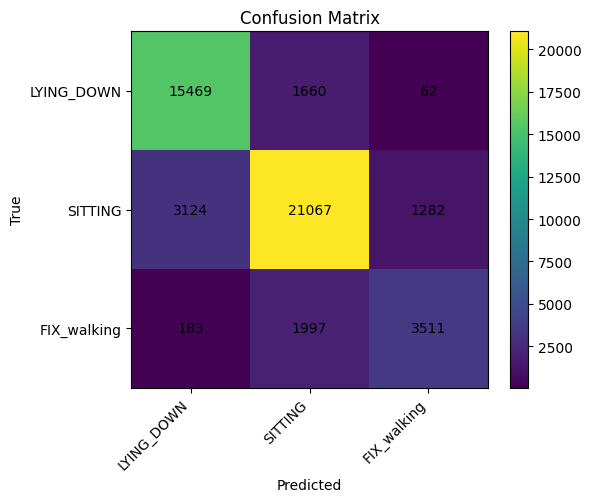

In [9]:
import matplotlib.pyplot as plt

cm = cm_fold0
plt.figure(figsize=(6,5))
plt.imshow(cm)
plt.xticks(range(3), TARGET_LABELS, rotation=45, ha="right")
plt.yticks(range(3), TARGET_LABELS)
plt.colorbar()
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")

# подписи чисел
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

### 5.3 Что это значит для Microbreak Assistant

Для ассистента микропауз ключевой триггер — SITTING. По результатам 5-fold оценки класс SITTING распознаётся стабильно (F1 0.807 ± 0.039), значит основная идея “замечать длительное сидение” реализуема.

Главный риск для продукта — ошибки вида walking → sitting, которые могут привести к лишнему уведомлению во время движения. Чтобы снизить раздражающие ложные уведомления, при внедрении важно использовать простые правила поверх модели:

не реагировать на одиночные минуты, а использовать правило “SITTING подряд N минут” (например, 45–60 минут),

применять временное сглаживание (majority vote по окну, например последние 10 минут),

(опционально) использовать порог уверенности и включать уведомления только при высокой уверенности в классе SITTING.

### 5.4 Заключение:
В среднем по 5 фолдам базовая модель демонстрирует хорошие результаты для SITTING и LYING_DOWN, что подтверждает реализуемость proof-of-concept Microbreak Assistant. Основным ограничением остаётся более слабое распознавание FIX_walking и вариативность качества между фолдами, однако практические правила внедрения (temporal smoothing и консервативные условия уведомлений) могут существенно снизить влияние ошибок на пользовательский опыт.

# 6. Deployment

### 6.1 Концепт “Microbreak Assistant”

Целью системы является ненавязчивое напоминание о микропаузах, когда пользователь долго находится в состоянии SITTING. Модель классифицирует каждую минуту на один из трёх классов: LYING_DOWN, SITTING, FIX_walking. Логика использования предсказаний:

SITTING → потенциальный триггер микропауз

LYING_DOWN → уведомления подавляются (возможен отдых/сон)

FIX_walking → уведомление не требуется, пользователь уже активен

### 6.2 Правило уведомлений (чтобы не раздражать)

Чтобы уменьшить ложные и раздражающие уведомления, ассистент не должен реагировать на одиночные предсказания. Вместо этого применяется временное сглаживание:

уведомление отправляется только если SITTING предсказывается непрерывно N минут (например, 45–60 минут);

можно использовать majority-vote по окну (например, последние 10 минут) или требовать, чтобы доля SITTING в окне превышала заданный порог;

параметр N должен быть настраиваемым (например, 30/45/60 минут) под предпочтения пользователя.

Это особенно важно, потому что по результатам 5-fold оценки класс FIX_walking распознаётся слабее, и часть минут ходьбы иногда ошибочно классифицируется как SITTING. Сглаживание во времени снижает влияние таких ошибок и делает поведение ассистента более “спокойным”.

### 6.3 Практическая реализация и ограничения

On-device processing: признаки могут рассчитываться на устройстве, а модель может работать локально, что улучшает приватность.

Персонализация: в будущем модель можно адаптировать под пользователя (например, под типичную посадку/манеру носить телефон), чтобы снизить путаницу между LYING_DOWN и SITTING.

Ограничения: датасет “in-the-wild” и self-reported метки; кроме того, мы упростили задачу, исключив multi-label минуты. Также наблюдается вариативность качества между группами пользователей (фолдами), поэтому результаты следует рассматривать как proof-of-concept, а правила уведомлений — делать консервативными.

### Summary

В этом проекте мы разработали proof-of-concept “Microbreak Assistant”, который по данным смартфонных сенсоров классифицирует активность пользователя на три состояния: LYING_DOWN, SITTING и FIX_walking. Мы использовали датасет ExtraSensory с готовыми признаками и оценили модель логистической регрессии в схеме One-vs-Rest с помощью user-based 5-fold cross-validation, чтобы проверить обобщаемость на ранее не встречавшихся пользователях. В среднем модель показывает хорошее качество для классов SITTING и LYING_DOWN, тогда как FIX_walking распознаётся сложнее, а качество варьируется между группами пользователей. Для практического применения предложена логика уведомлений с временным сглаживанием и консервативными правилами (например, триггер только при длительном непрерывном сидении), что снижает риск ложных и раздражающих напоминаний.

## References
- ExtraSensory Dataset (UC San Diego): https://extrasensory.ucsd.edu/
- Vaizman, Ellis, Lanckriet. “Recognizing Detailed Human Context In-the-Wild from Smartphones and Smart-watches.” arXiv:1609.06354: https://arxiv.org/abs/1609.06354